In [ ]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import load_raw_data
from src import config

df = load_raw_data()

Loading data from C:\Users\yahal\Documents\Personal\Projects\Energy-Forecasting-Pipeline\data\energy_data_set.csv...
Data loaded successfully. Shape: (19735, 28)
ime range: 2016-01-11 17:00:00 to 2016-05-27 18:00:00


In [5]:
df.info()
display(df.describe().T)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 19735 entries, 2016-01-11 17:00:00 to 2016-05-27 18:00:00
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Appliances   19735 non-null  int64  
 1   lights       19735 non-null  int64  
 2   T1           19735 non-null  float64
 3   RH_1         19735 non-null  float64
 4   T2           19735 non-null  float64
 5   RH_2         19735 non-null  float64
 6   T3           19735 non-null  float64
 7   RH_3         19735 non-null  float64
 8   T4           19735 non-null  float64
 9   RH_4         19735 non-null  float64
 10  T5           19735 non-null  float64
 11  RH_5         19735 non-null  float64
 12  T6           19735 non-null  float64
 13  RH_6         19735 non-null  float64
 14  T7           19735 non-null  float64
 15  RH_7         19735 non-null  float64
 16  T8           19735 non-null  float64
 17  RH_8         19735 non-null  float64
 18  T9         

,count,mean,std,min,25%,50%,75%,max
Appliances,19735.0,97.694958,102.524891,10.000000,50.000000,60.000000,100.000000,1080.000000
lights,19735.0,3.801875,7.935988,0.000000,0.000000,0.000000,0.000000,70.000000
T1,19735.0,21.686571,1.606066,16.790000,20.760000,21.600000,22.600000,26.260000
RH_1,19735.0,40.259739,3.979299,27.023333,37.333333,39.656667,43.066667,63.360000
T2,19735.0,20.341219,2.192974,16.100000,18.790000,20.000000,21.500000,29.856667
RH_2,19735.0,40.420420,4.069813,20.463333,37.900000,40.500000,43.260000,56.026667
T3,19735.0,22.267611,2.006111,17.200000,20.790000,22.100000,23.290000,29.236000
RH_3,19735.0,39.242500,3.254576,28.766667,36.900000,38.530000,41.760000,50.163333
T4,19735.0,20.855335,2.042884,15.100000,19.530000,20.666667,22.100000,26.200000
RH_4,19735.0,39.026904,4.341321,27.660000,35.530000,38.400000,42.156667,51.090000


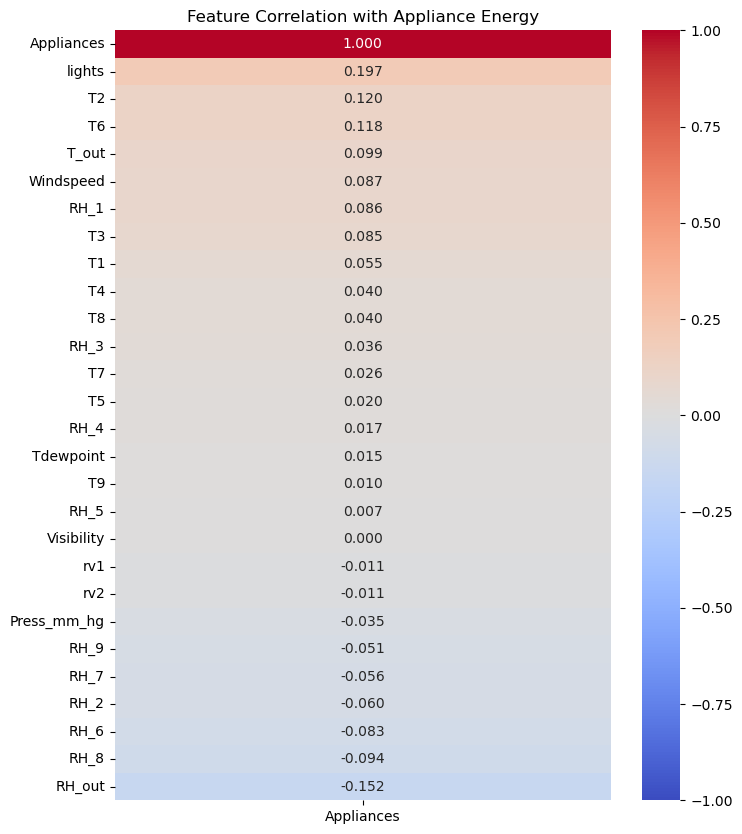

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Isolate the numeric columns for the correlation matrix
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Calculate how every feature correlates specifically with the Target
corr = numeric_df.corr()[['Appliances']].sort_values(by='Appliances', ascending=False)

# Visualize the math
plt.figure(figsize=(8, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.3f', vmin=-1, vmax=1)
plt.title('Feature Correlation with Appliance Energy')
plt.show()

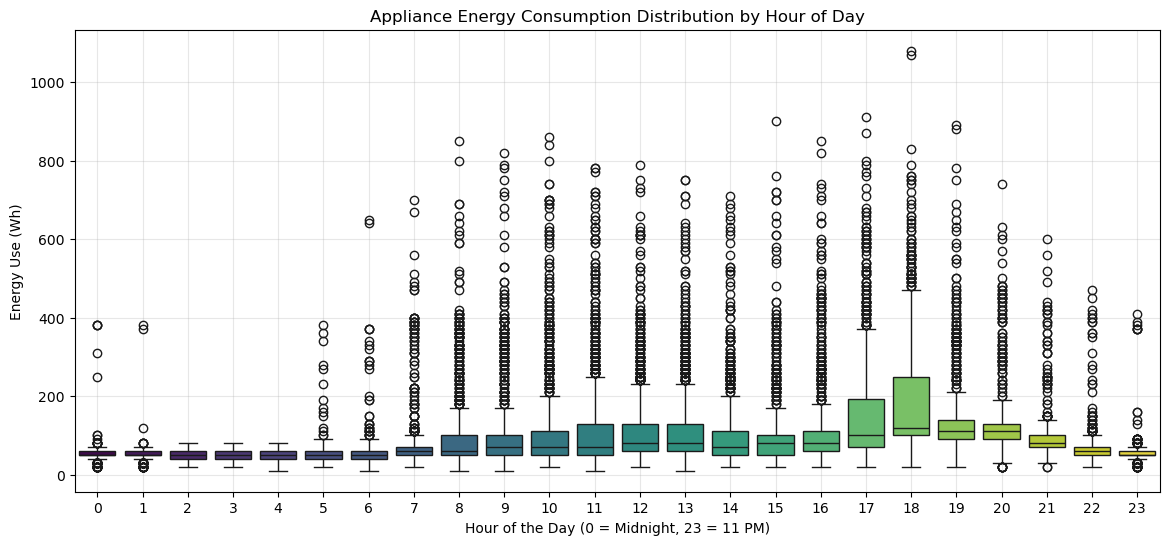

In [8]:


# A temporary hour column for visualization
df_eda = df.copy()
df_eda['hour'] = df_eda.index.hour

plt.figure(figsize=(14, 6))
# Boxplots show the median, spread, and extreme outliers for every single hour
sns.boxplot(x='hour', y='Appliances', data=df_eda, hue='hour', palette='viridis', legend=False)
plt.title('Appliance Energy Consumption Distribution by Hour of Day')
plt.xlabel('Hour of the Day (0 = Midnight, 23 = 11 PM)')
plt.ylabel('Energy Use (Wh)')
plt.grid(True, alpha=0.3)
plt.show()

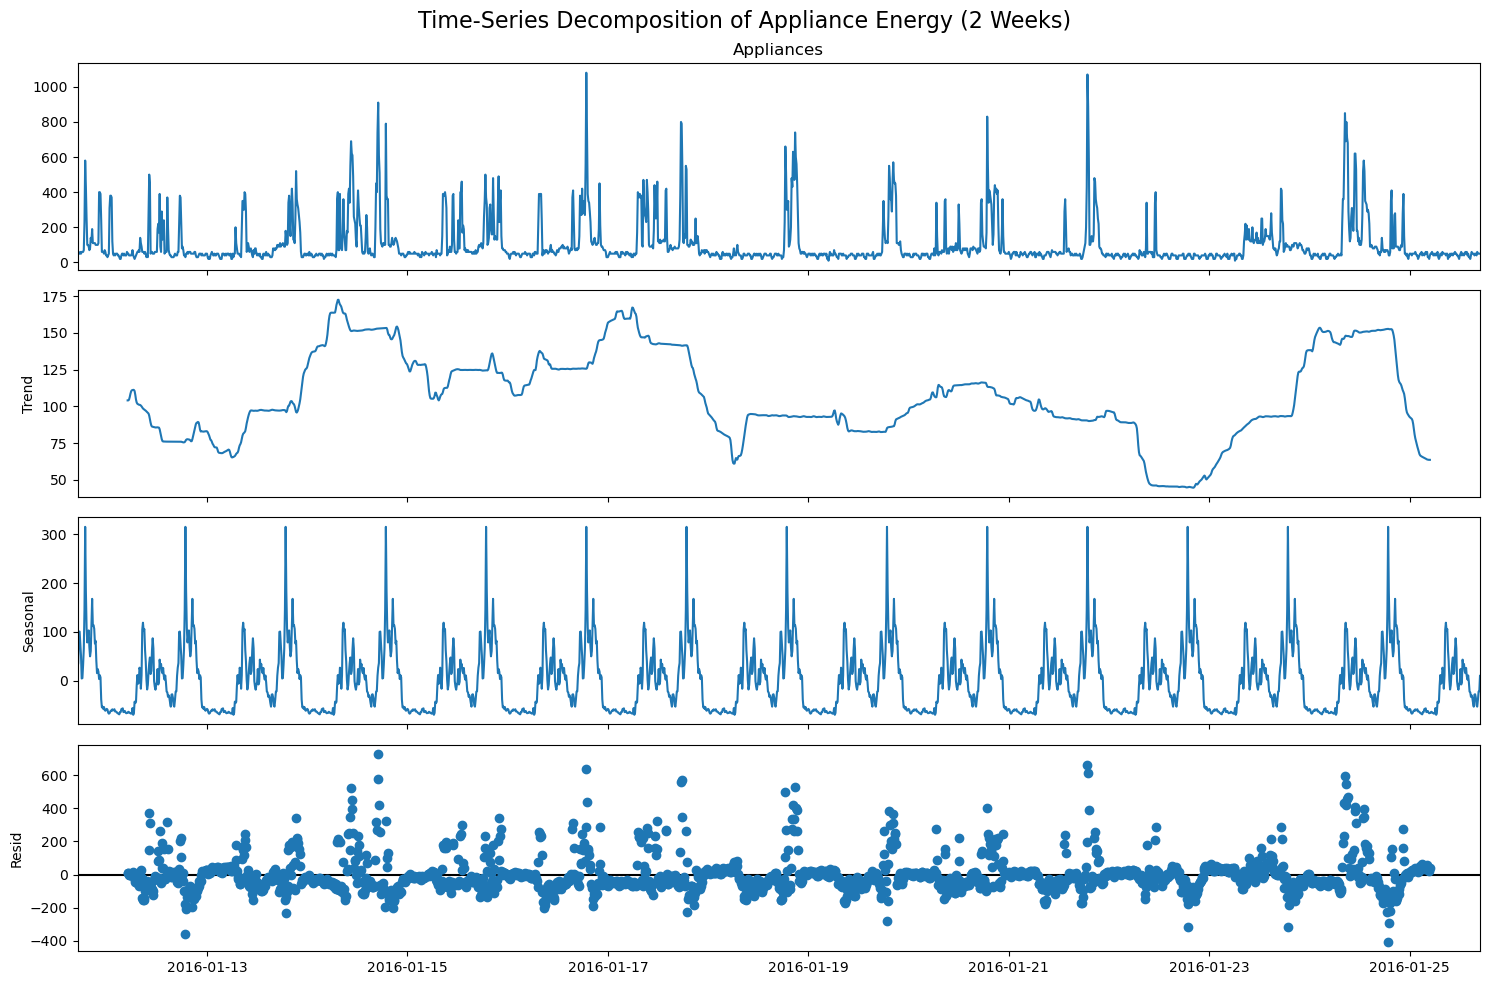

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 2 weeks of data so the chart isn't compressed too muvh
# 10-minute intervals: 6 per hour * 24 hours * 14 days = 2016 rows
subset = df['Appliances'][:2016]

# Period = 144 (24 hours of 10-minute intervals)
decomposition = seasonal_decompose(subset, model='additive', period=144)

fig = decomposition.plot()
fig.set_size_inches(15, 10)
plt.suptitle('Time-Series Decomposition of Appliance Energy (2 Weeks)', fontsize=16)
plt.tight_layout()
plt.show()

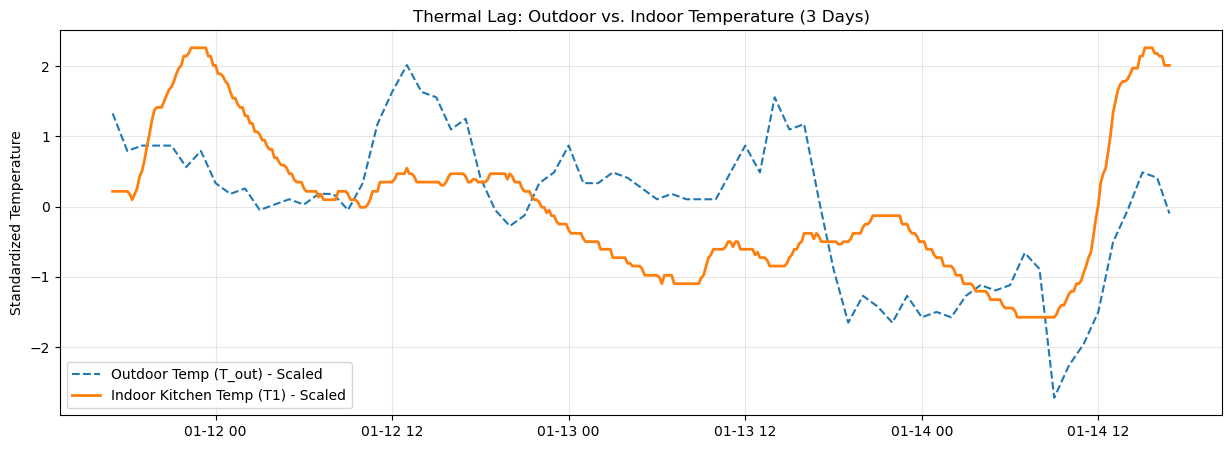

In [10]:
plt.figure(figsize=(15, 5))

# 3 days of temperature data
days_to_plot = 6 * 24 * 3 

# Normalize the data
t_out_scaled = (df['T_out'][:days_to_plot] - df['T_out'][:days_to_plot].mean()) / df['T_out'][:days_to_plot].std()
t1_scaled = (df['T1'][:days_to_plot] - df['T1'][:days_to_plot].mean()) / df['T1'][:days_to_plot].std()

plt.plot(df.index[:days_to_plot], t_out_scaled, label='Outdoor Temp (T_out) - Scaled', linestyle='--')
plt.plot(df.index[:days_to_plot], t1_scaled, label='Indoor Kitchen Temp (T1) - Scaled', linewidth=2)

plt.title('Thermal Lag: Outdoor vs. Indoor Temperature (3 Days)')
plt.ylabel('Standardized Temperature')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

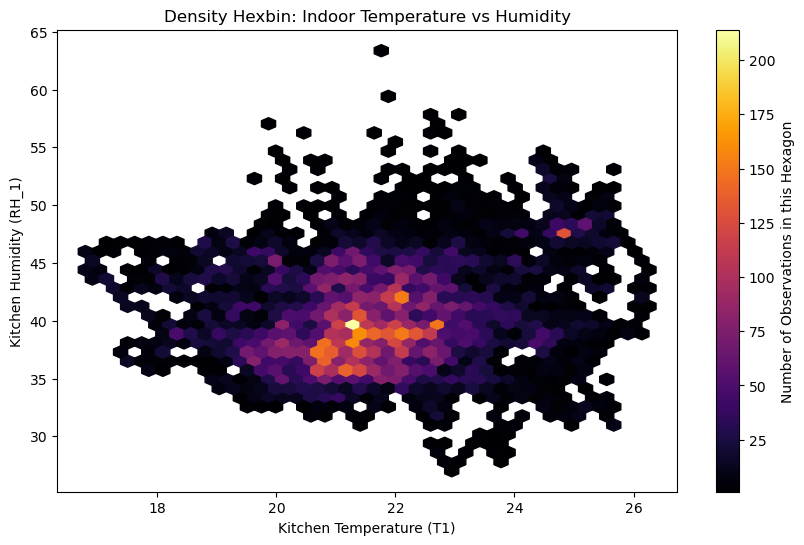

In [11]:
plt.figure(figsize=(10, 6))

hb = plt.hexbin(df['T1'], df['RH_1'], gridsize=40, cmap='inferno', mincnt=1)
plt.colorbar(hb, label='Number of Observations in this Hexagon')

plt.title('Density Hexbin: Indoor Temperature vs Humidity')
plt.xlabel('Kitchen Temperature (T1)')
plt.ylabel('Kitchen Humidity (RH_1)')
plt.show()

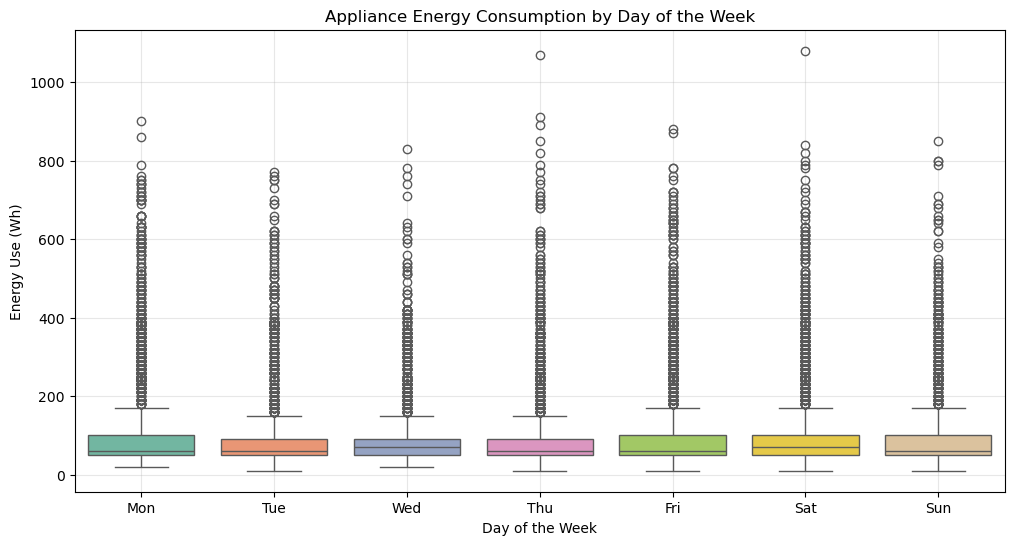

In [14]:
import calendar

df_eda = df.copy()
df_eda['day_of_week'] = df_eda.index.dayofweek

# Maps the integers (0-6) to actual day names for a readable chart
day_mapping = {i: calendar.day_abbr[i] for i in range(7)}
df_eda['day_name'] = df_eda['day_of_week'].map(day_mapping)

plt.figure(figsize=(12, 6))
sns.boxplot(x='day_name', y='Appliances', data=df_eda, hue='day_name', palette='Set2', 
            order=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], legend=False)
plt.title('Appliance Energy Consumption by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Energy Use (Wh)')
plt.grid(True, alpha=0.3)
plt.show()

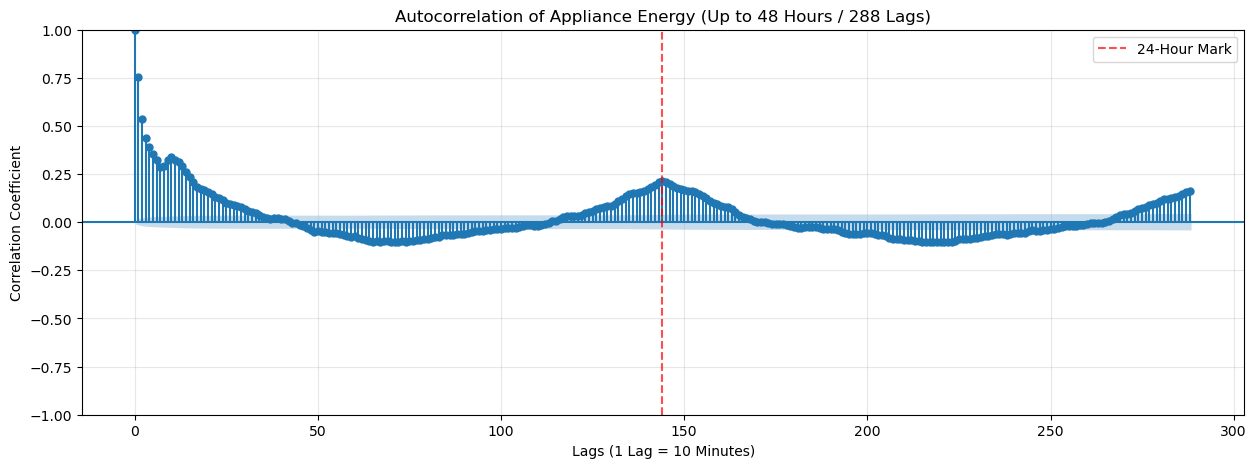

In [15]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(15, 5))
# Lags = 288 (48 hours of 10-minute intervals: 6 * 24 * 2)
plot_acf(df['Appliances'], lags=288, alpha=0.05, ax=plt.gca())

plt.title('Autocorrelation of Appliance Energy (Up to 48 Hours / 288 Lags)')
plt.xlabel('Lags (1 Lag = 10 Minutes)')
plt.ylabel('Correlation Coefficient')
plt.grid(True, alpha=0.3)

plt.axvline(x=144, color='red', linestyle='--', alpha=0.7, label='24-Hour Mark')
plt.legend()
plt.show()